# Downtime and OEE

Which losses and machines deserve investigation?

**Synthetic steel fabrication portfolio. No confidential company data or real-plant improvement claims.**

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Start from the repository or notebooks folder'
sys.path.insert(0, str(ROOT / 'src'))
from cleaning import clean_data
from kpi import summarize, grouped, pareto, operation_capacity
raw = pd.read_csv(ROOT / 'data/raw/manufacturing_data.csv')
clean = clean_data(raw)


,downtime_reason,lost_time_min,share,cumulative_share
0,Setup,85526,0.407259,0.407259
1,Material shortage,35128,0.167273,0.574532
2,Tool change,32372,0.154149,0.728681
3,Machine failure,24594,0.117112,0.845793
4,Maintenance,11798,0.056180,0.901973
5,Quality issue,10373,0.049394,0.951368
6,Operator waiting,10213,0.048632,1.000000


,machine_id,availability,performance,quality,oee
0,INSPECT_01,0.880280,0.895909,0.979965,0.772850
1,LATHE_01,0.883177,0.898352,0.980388,0.777843
2,PACK_01,0.882794,0.900021,0.980980,0.779421
3,PRESS_600T,0.839280,0.896500,0.980494,0.737738
4,PRESS_60T,0.883951,0.899427,0.979631,0.778854
5,WELD_01,0.883770,0.799806,0.944558,0.667655
6,WELD_10HEAD,0.882535,0.803525,0.944956,0.670105


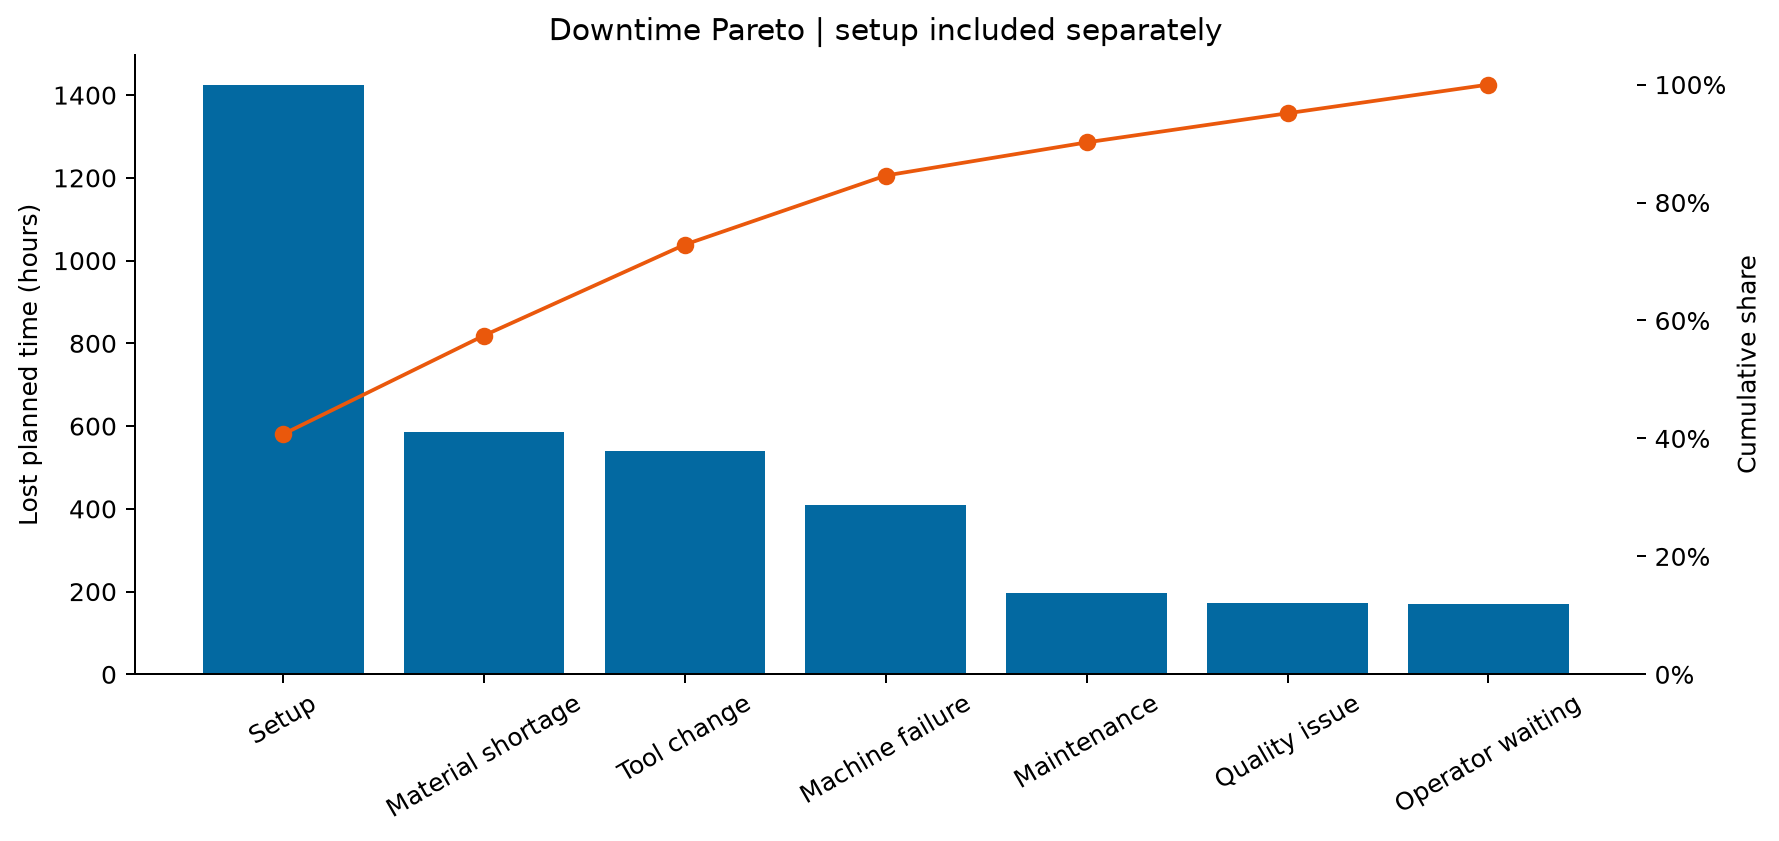

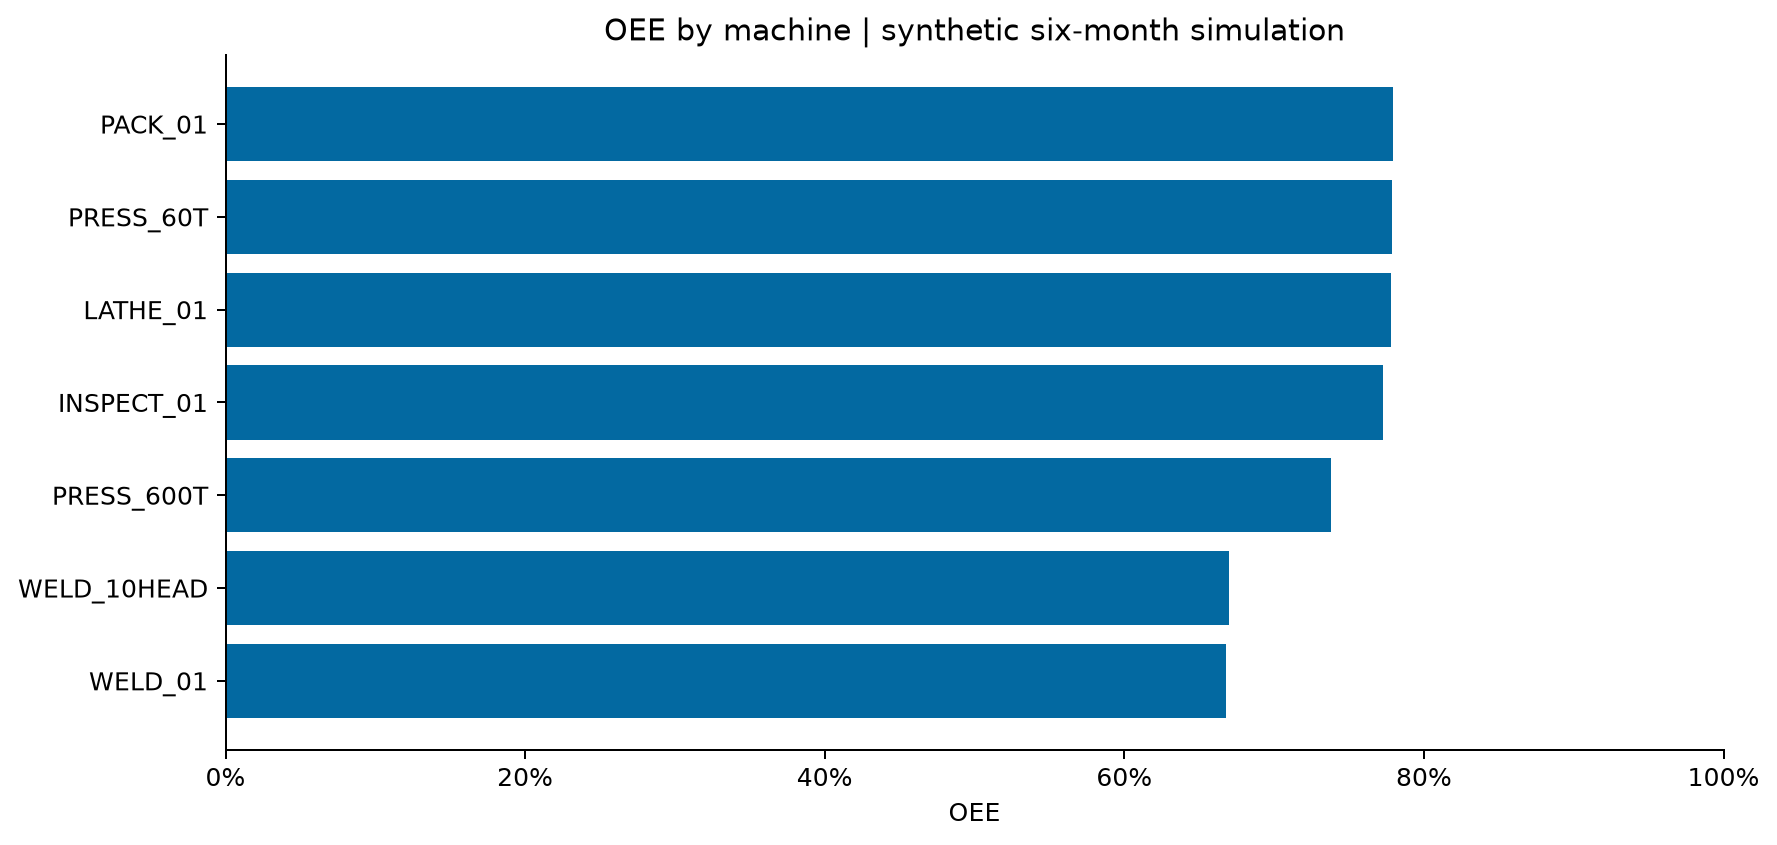

In [2]:
display(pd.read_csv(ROOT / 'data/processed/downtime_pareto.csv'))
display(grouped(clean,'machine_id')[['machine_id','availability','performance','quality','oee']])
display(Image(filename=str(ROOT / 'reports/figures/downtime_pareto.png')))
display(Image(filename=str(ROOT / 'reports/figures/oee_by_machine.png')))

## Interpretation

Setup and categorized downtime are separate, mutually exclusive losses. Pool denominators before calculating OEE; never average percentages directly.

See docs/methodology.md for definitions and limitations.